# Chapter 5

## Classification and Regression Trees, Ensembles, and Deep Learning Models – what’s best for your data?

This notebook is a companion to the book _XGBoost for Regression Predictive Modeling and Time Series Analysis_.
This chapter builds on the work you did in chapter four. In chapter four, you built a regression model to predict the value of a house based on multiple parameters. We will use the same dataset to examine the preformance of different models: CART, gradient boosted trees, random forest, and XGBoost


# Setting up the python environment and ingesting the housing dataset


In [1]:
# ----------------------------------------
# filename housingvaluemodelcomparison.ipynb
# purpose compare predictions of house value
# by different models
# author Joyce Weiner
# revision 1.0
# revision history 1.0 - initial script
# ----------------------------------------

import pandas as pd

In [2]:
# load the California Housing data set from scikit-learn
from sklearn import datasets

housingX, housingy = datasets.fetch_california_housing(return_X_y=True, as_frame=True)

In [3]:
housingX.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [4]:
housingy.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

## Data preparation

Next, we'll split the data into training and test sets using the scikit-learn train_test_split function


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    housingX, housingy, test_size=0.2, random_state=17
)

## Comparing XGBoost to linear regression and CART

Now let's see how a linear fit model performs. We'll fit the data and look at the RMSE and R<sup>2</sup> values.

### Linear regression


In [6]:
%%time
from sklearn.linear_model import LinearRegression

housing_linear_regression = LinearRegression().fit(X_train, y_train)

CPU times: total: 188 ms
Wall time: 256 ms


In [7]:
%%time
from sklearn.metrics import root_mean_squared_error

housing_linreg_ypred = housing_linear_regression.predict(X_test)

CPU times: total: 0 ns
Wall time: 2.74 ms


Linear regression RMSE calculation


In [8]:
housing_linreg_rmse = root_mean_squared_error(
    y_true=y_test, y_pred=housing_linreg_ypred
)
print("Linear regression RMSE is {0:.2f}".format(housing_linreg_rmse))

Linear regression RMSE is 0.72


Linear regression R<sup>2</sup> calculation


In [9]:
housing_linreg_r2 = housing_linear_regression.score(X_test, y_test)
print("Linear regression Rsquared is {0:.2f}".format(housing_linreg_r2))

Linear regression Rsquared is 0.60


Plot the predicted versus true values for the text dataset


<Axes: xlabel='MedHouseVal'>

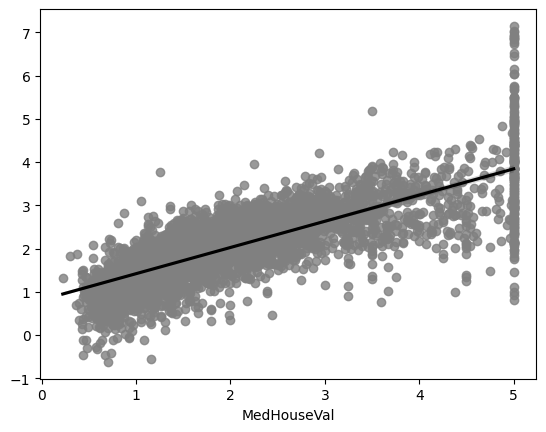

In [10]:
import seaborn as sns

sns.regplot(
    x=y_test,
    y=housing_linreg_ypred,
    scatter_kws={"color": "grey"},
    line_kws={"color": "black"},
)

### Classification and Regression Tree (CART)


In [11]:
%%time
from sklearn.tree import DecisionTreeRegressor

housing_CART = DecisionTreeRegressor()
housing_CART_regression = housing_CART.fit(X_train, y_train)

CPU times: total: 359 ms
Wall time: 395 ms


In [12]:
%%time
housing_cart_ypred = housing_CART_regression.predict(X_test)

CPU times: total: 0 ns
Wall time: 4.03 ms


CART RMSE


In [ ]:
housing_cart_rmse = root_mean_squared_error(y_true=y_test, y_pred=housing_cart_ypred)
print("CART RMSE is {0:.2f}".format(housing_cart_rmse))


CART RMSE is 0.72


CART R<sup>2</sup>


In [14]:
housing_cart_r2 = housing_CART_regression.score(X_test, y_test)
print("CART Rsquared is {0:.2f}".format(housing_cart_r2))

CART Rsquared is 0.60


<Axes: xlabel='MedHouseVal'>

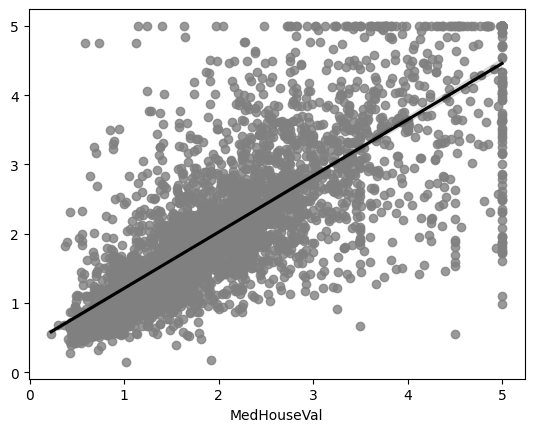

In [15]:
sns.regplot(
    x=y_test,
    y=housing_cart_ypred,
    scatter_kws={"color": "grey"},
    line_kws={"color": "black"},
)

In [ ]:
# Plotting the tree takes over 20 minutes, uncomment this cell if you'd like to execute it yourself
# from sklearn import tree
# tree.plot_tree(housing_CART)

## Comparing XGBoost to gradient boosting, and random forest


Gradient Boosting in scikit-learn


In [16]:
%%time
from sklearn.ensemble import GradientBoostingRegressor

housing_gbt = GradientBoostingRegressor(random_state=17, max_depth=6)
housing_gbt_regression = housing_gbt.fit(X_train, y_train)

CPU times: total: 6.23 s
Wall time: 6.31 s


In [17]:
%%time
housing_gbt_ypred = housing_gbt_regression.predict(X_test)

CPU times: total: 31.2 ms
Wall time: 32.3 ms


In [18]:
housing_gbt_rmse = root_mean_squared_error(y_true=y_test, y_pred=housing_gbt_ypred)
print("Gradient boosting regressor RMSE is {0:.2f}".format(housing_gbt_rmse))

Gradient boosting regressor RMSE is 0.49


In [19]:
housing_gbt_r2 = housing_gbt_regression.score(X_test, y_test)
print("Gradient boosting regressor Rsquared is {0:.2f}".format(housing_gbt_r2))

Gradient boosting regressor Rsquared is 0.82


<Axes: xlabel='MedHouseVal'>

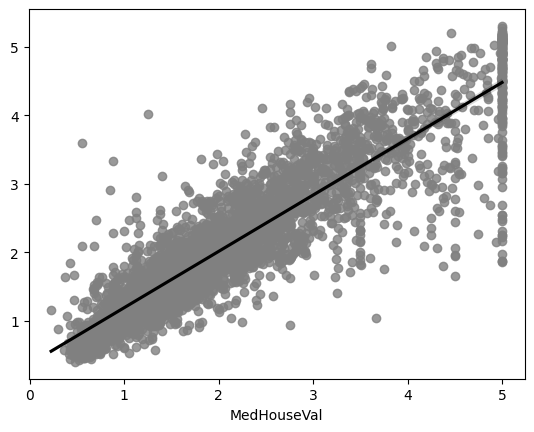

In [20]:
sns.regplot(
    x=y_test,
    y=housing_gbt_ypred,
    scatter_kws={"color": "grey"},
    line_kws={"color": "black"},
)

Random forest in scikit-learn


In [21]:
%%time
from sklearn.ensemble import RandomForestRegressor

housing_rf = RandomForestRegressor(random_state=17)
housing_rf_regression = housing_rf.fit(X_train, y_train)

CPU times: total: 12.2 s
Wall time: 12.6 s


In [22]:
%%time
housing_rf_ypred = housing_rf_regression.predict(X_test)

CPU times: total: 141 ms
Wall time: 135 ms


In [23]:
housing_rf_rmse = root_mean_squared_error(y_true=y_test, y_pred=housing_rf_ypred)
print("Random Forest RMSE is {0:.2f}".format(housing_rf_rmse))

Random Forest RMSE is 0.51


In [24]:
housing_rf_r2 = housing_rf_regression.score(X_test, y_test)
print("Random forest Rsquared is {0:.2f}".format(housing_gbt_r2))

Random forest Rsquared is 0.82


<Axes: xlabel='MedHouseVal'>

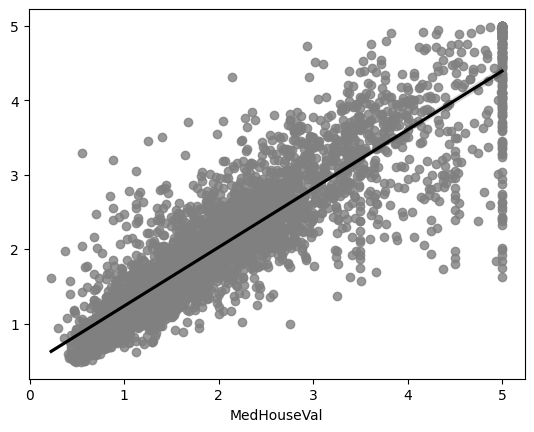

In [25]:
sns.regplot(
    x=y_test,
    y=housing_rf_ypred,
    scatter_kws={"color": "grey"},
    line_kws={"color": "black"},
)

## XGBoost model settings and model training

this code is the same as in Chapter 4 and is repeated here so you can reference the execution time and RMSE and R<sup>2</sup> values


In [26]:
%%time
import xgboost as xgb
from sklearn.metrics import r2_score


housevalue_regressor = xgb.XGBRegressor()

housevalue_regressor.fit(
    X_train, y_train, eval_set=[(X_test, y_test), (X_train, y_train)]
)

[0]	validation_0-rmse:0.93417	validation_1-rmse:0.93744
[1]	validation_0-rmse:0.80544	validation_1-rmse:0.79501
[2]	validation_0-rmse:0.72406	validation_1-rmse:0.70244
[3]	validation_0-rmse:0.66749	validation_1-rmse:0.63818
[4]	validation_0-rmse:0.63751	validation_1-rmse:0.60033
[5]	validation_0-rmse:0.61189	validation_1-rmse:0.56644
[6]	validation_0-rmse:0.58620	validation_1-rmse:0.53308
[7]	validation_0-rmse:0.57241	validation_1-rmse:0.51228
[8]	validation_0-rmse:0.56593	validation_1-rmse:0.50156
[9]	validation_0-rmse:0.55121	validation_1-rmse:0.48426
[10]	validation_0-rmse:0.54240	validation_1-rmse:0.47137
[11]	validation_0-rmse:0.53708	validation_1-rmse:0.46342
[12]	validation_0-rmse:0.53323	validation_1-rmse:0.45607
[13]	validation_0-rmse:0.53001	validation_1-rmse:0.45001
[14]	validation_0-rmse:0.52530	validation_1-rmse:0.44200
[15]	validation_0-rmse:0.52239	validation_1-rmse:0.43719
[16]	validation_0-rmse:0.52073	validation_1-rmse:0.43158
[17]	validation_0-rmse:0.51860	validation

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [27]:
%%time
y_score = housevalue_regressor.predict(X_test)

CPU times: total: 0 ns
Wall time: 8.84 ms


In [28]:
xgboost_rmse = root_mean_squared_error(y_true=y_test, y_pred=y_score)
print("XGBoost RMSE is {0:.2f}".format(xgboost_rmse))

XGBoost RMSE is 0.49


In [29]:
xgboost_r2 = r2_score(y_true=y_test, y_pred=y_score)
print("XGBoost Rsquared is {0:.2f}".format(xgboost_r2))

XGBoost Rsquared is 0.82


<Axes: xlabel='MedHouseVal'>

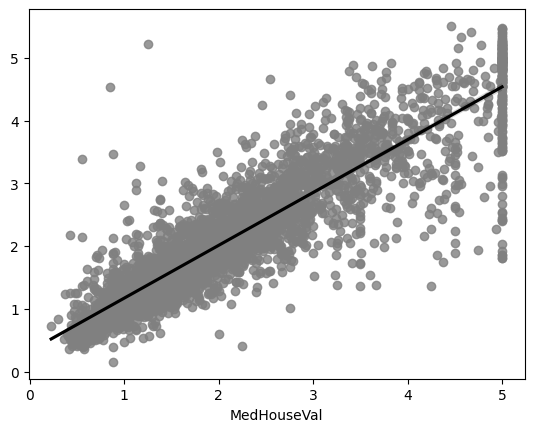

In [30]:
sns.regplot(
    x=y_test, y=y_score, scatter_kws={"color": "grey"}, line_kws={"color": "black"}
)

In [31]:
residuals = y_test - y_score
X_testResiduals = pd.concat([X_test, residuals], axis=1)

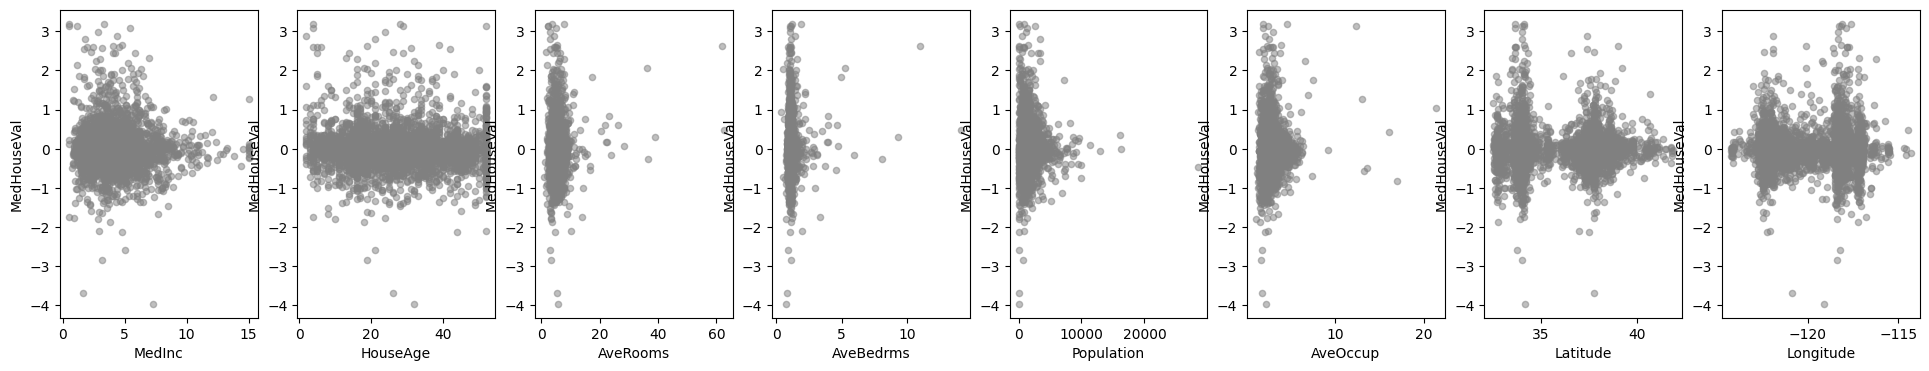

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=8, figsize=(24, 4))

for xcol, ax in zip(X_test.loc[:].columns, axes):
    X_testResiduals.plot(
        kind="scatter", x=xcol, y="MedHouseVal", ax=ax, alpha=0.5, color="grey"
    )

Compare gradient boosting preditions to XGBoost predictions


<Axes: >

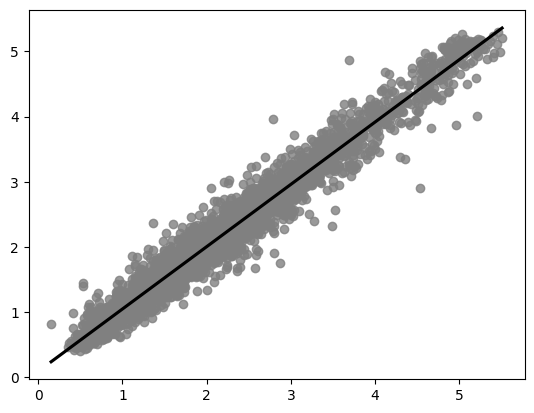

In [33]:
sns.regplot(
    x=y_score,
    y=housing_gbt_ypred,
    scatter_kws={"color": "grey"},
    line_kws={"color": "black"},
)

Compare random forest predictions to XGBoost predictions


<Axes: >

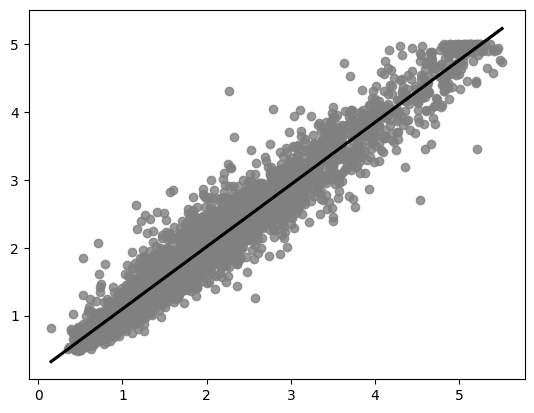

In [34]:
sns.regplot(
    x=y_score,
    y=housing_rf_ypred,
    scatter_kws={"color": "grey"},
    line_kws={"color": "black"},
)